In [100]:
"""
обучение весов на всей выборке (N=20) с λ = 0.5.
Результат — рабочий вектор w* для применения к большой выборке.
"""

import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import pearsonr
from mealpy import PSO, FloatVar
import warnings, os, csv
warnings.filterwarnings('ignore')

mpl.rcParams['font.family']    = 'serif'
mpl.rcParams['font.serif']     = ['Times New Roman', 'DejaVu Serif']
mpl.rcParams['axes.titlesize'] = 12
mpl.rcParams['axes.labelsize'] = 11
mpl.rcParams['xtick.labelsize']= 10
mpl.rcParams['ytick.labelsize']= 10
mpl.rcParams['legend.fontsize']= 10

os.makedirs('/mnt/user-data/outputs', exist_ok=True)

# ── данные ────────────────────────────────────────────────────────────────────
E      = np.load('E_articles.npy')
Smats  = {
    'TF-IDF':   np.load('S_tfidf_articles.npy'),
    'Word2Vec': np.load('S_w2v_articles.npy'),
    'BERT':     np.load('S_bert_articles.npy'),
    'LDA':      np.load('S_lda_articles.npy'),
    'ICAN':     np.load('S_ican_articles.npy'),
}
metric_names = list(Smats.keys())
S_stack = np.stack(list(Smats.values()), axis=0)
N, K = E.shape[0], len(metric_names)

LAM    = 0.5
N_RUNS = 10  # больше запусков — надёжнее финальный результат

# ── целевая функция ───────────────────────────────────────────────────────────
def objective(solution):
    w = np.clip(np.array(solution), 0, None)
    s = w.sum()
    if s < 1e-12:
        return 1e9
    w = w / s
    A    = np.einsum('k,kij->ij', w, S_stack)
    frob = np.sum((A - E) ** 2)
    w_safe = np.where(w > 1e-12, w, 1e-12)
    entropy = -np.sum(w_safe * np.log(w_safe))
    return frob - LAM * entropy

# ── 10 запусков PSO, берём лучший ────────────────────────────────────────────
print(f"Предварительное обучение на N={N} объектах, λ={LAM}, {N_RUNS} запусков PSO")
print("-" * 55)

best_w, best_f = None, np.inf
run_results = []

for run in range(N_RUNS):
    problem = {
        'obj_func': objective,
        'bounds':   FloatVar(lb=[0.0]*K, ub=[1.0]*K),
        'minmax':   'min',
        'log_to':   None,
        'save_population': False,
    }
    np.random.seed(42 + run)
    model = PSO.OriginalPSO(epoch=100, pop_size=50)  # больше итераций
    model.solve(problem, seed=42 + run)

    w_raw  = np.clip(np.array(model.g_best.solution), 0, None)
    w_norm = w_raw / w_raw.sum()
    f_val  = objective(w_norm)

    # корреляция на всей матрице (внедиагональные элементы)
    A = np.einsum('k,kij->ij', w_norm, S_stack)
    mask = ~np.eye(N, dtype=bool)
    r, p = pearsonr(A[mask], E[mask])

    run_results.append((f_val, w_norm, r))
    print(f"  Запуск {run+1:2d}: F={f_val:.6f}  r={r:.4f}  "
          f"w=[{', '.join(f'{wi:.3f}' for wi in w_norm)}]")

    if f_val < best_f:
        best_f, best_w = f_val, w_norm

# ── финальные метрики ─────────────────────────────────────────────────────────
A_final = np.einsum('k,kij->ij', best_w, S_stack)
mask    = ~np.eye(N, dtype=bool)
r_final, p_final = pearsonr(A_final[mask], E[mask])

# корреляции одиночных метрик для сравнения
single_r = {}
for name, S in Smats.items():
    r, _ = pearsonr(S[mask], E[mask])
    single_r[name] = r
best_single     = max(single_r, key=single_r.get)
improvement_pct = (r_final - single_r[best_single]) / abs(single_r[best_single]) * 100

print(f"\n{'='*55}")
print(f"ПРЕДВАРИТЕЛЬНЫЕ ВЕСА (лучший запуск, λ={LAM})")
print(f"{'='*55}")
for name, w in zip(metric_names, best_w):
    bar = '█' * int(w * 40)
    print(f"  {name:<10}: {w:.4f}  ({w*100:5.1f}%)  {bar}")

print(f"\nКорреляция Пирсона r = {r_final:.4f}  (p = {p_final:.2e})")
print(f"Лучшая одиночная ({best_single}): r = {single_r[best_single]:.4f}")
print(f"Улучшение: {improvement_pct:+.2f}%")

# стабильность 10 запусков
W_runs = np.stack([res[1] for res in run_results], axis=0)
print(f"\nСтабильность по {N_RUNS} запускам:")
print(f"{'Метрика':<12} {'Среднее':>8} {'Std':>8} {'CV,%':>7}")
for k, name in enumerate(metric_names):
    mu  = W_runs[:, k].mean()
    std = W_runs[:, k].std()
    cv  = std / mu * 100 if mu > 1e-9 else float('nan')
    print(f"  {name:<10} {mu:>8.4f} {std:>8.4f} {cv:>7.1f}")

# ── График 1: итоговые веса (горизонтальная столбчатая диаграмма) ─────────────
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#2C5F8A', '#3D7DA8', '#5A9DBF', '#A0C4D8', '#C8DFF0']
bars = ax.barh(metric_names[::-1], best_w[::-1] * 100,
               color=colors, edgecolor='white', height=0.6, zorder=3)
for bar, w in zip(bars, best_w[::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{w*100:.1f}%', va='center', fontsize=10)
ax.set_xlabel('Весовой коэффициент, %')
ax.set_title(f'Финальные веса метрик (λ = {LAM}, N = {N})\n'
             f'r = {r_final:.4f}, улучшение относительно лучшей одиночной: {improvement_pct:+.1f}%')
ax.set_xlim(0, max(best_w) * 100 * 1.25)
ax.grid(axis='x', linestyle=':', alpha=0.5, zorder=0)
plt.tight_layout()
plt.savefig('final_weights.png', dpi=150, bbox_inches='tight')
plt.close()

# ── График 2: сравнение комбинации с одиночными метриками ─────────────────────
all_names = metric_names + ['Комбинация\n(PSO, λ=0,5)']
all_r     = [single_r[n] for n in metric_names] + [r_final]
bar_colors = ['#A0C4D8'] * K + ['#2C5F8A']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(all_names, all_r, color=bar_colors, zorder=3, edgecolor='white')
ax.axhline(single_r[best_single], color='#C0392B', linestyle='--',
           linewidth=1.2, label=f'Лучшая одиночная ({best_single}): r={single_r[best_single]:.4f}')
for bar, r in zip(bars, all_r):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{r:.4f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Корреляция Пирсона r с экспертной матрицей')
ax.set_title('Корреляция одиночных метрик и комбинации\nс экспертной матрицей (вся выборка, N=20)')
ax.set_ylim(min(0, min(all_r)) - 0.05, 1.0)
ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.5, zorder=0)
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.close()

# ── сохраняем веса ────────────────────────────────────────────────────────────
np.save('final_weights_lambda05.npy', best_w)

with open('final_weights_lambda05.csv', 'w',
          newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(['Метрика', 'Вес', 'Процент'])
    for name, w in zip(metric_names, best_w):
        writer.writerow([name, round(w, 6), round(w*100, 2)])
    writer.writerow(['r_combined', round(r_final, 6), ''])
    writer.writerow(['p_value',    round(p_final, 6), ''])
    writer.writerow(['lambda',     LAM, ''])

print("\nФайлы сохранены:")
print("  final_weights_lambda05.npy  — веса для применения к большой выборке")
print("  final_weights_lambda05.csv  — таблица для диссертации")
print("  final_weights.png           — график весов")
print("  final_comparison.png        — сравнение с одиночными метриками")
print("\nГотово.")

Предварительное обучение на N=20 объектах, λ=0.5, 10 запусков PSO
-------------------------------------------------------
  Запуск  1: F=6.408925  r=0.5977  w=[0.291, 0.175, 0.002, 0.206, 0.325]
  Запуск  2: F=6.408925  r=0.5977  w=[0.291, 0.175, 0.002, 0.206, 0.325]
  Запуск  3: F=6.408925  r=0.5977  w=[0.291, 0.175, 0.002, 0.206, 0.325]
  Запуск  4: F=6.408925  r=0.5977  w=[0.291, 0.175, 0.002, 0.206, 0.325]
  Запуск  5: F=6.408925  r=0.5977  w=[0.291, 0.175, 0.002, 0.206, 0.325]
  Запуск  6: F=6.408925  r=0.5977  w=[0.291, 0.175, 0.002, 0.206, 0.325]
  Запуск  7: F=6.408925  r=0.5977  w=[0.291, 0.175, 0.002, 0.206, 0.325]
  Запуск  8: F=6.408925  r=0.5977  w=[0.291, 0.175, 0.002, 0.206, 0.325]
  Запуск  9: F=6.408925  r=0.5977  w=[0.291, 0.175, 0.002, 0.206, 0.325]
  Запуск 10: F=6.408925  r=0.5977  w=[0.291, 0.175, 0.002, 0.206, 0.325]

ПРЕДВАРИТЕЛЬНЫЕ ВЕСА (лучший запуск, λ=0.5)
  TF-IDF    : 0.2913  ( 29.1%)  ███████████
  Word2Vec  : 0.1748  ( 17.5%)  ██████
  BERT      : 0.0024

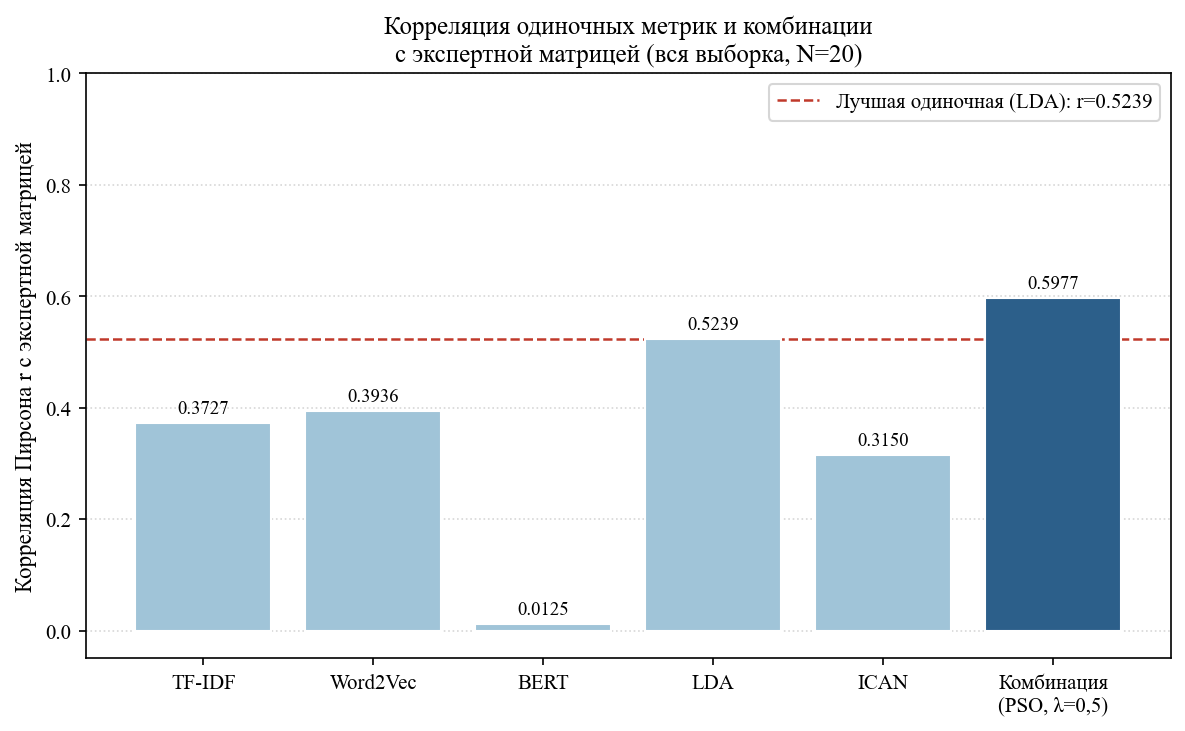

In [49]:
Image(filename="final_comparison.png", width=600, height=500) #предварительные веса без регуляризации

In [11]:
"""
Кросс-валидация с энтропийной регуляризацией весов.

Целевая функция:
    F(w, λ) = ||A(w) − E||²_F  +  λ · Σ wₖ · ln(wₖ)

Второй член — отрицательная энтропия Шеннона.
При λ=0 — исходная задача.
При λ→∞ — веса стремятся к равномерным.

Перебираем λ ∈ {0, 0.01, 0.05, 0.1, 0.3, 0.5}.
По каждому λ: 5-fold CV → среднее r и CV весов.
Выбираем λ с наилучшим балансом r и стабильности.
"""

import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import pearsonr
from mealpy import PSO, FloatVar
import warnings, os
warnings.filterwarnings('ignore')

# ── шрифт ────────────────────────────────────────────────────────────────────
mpl.rcParams['font.family']    = 'serif'
mpl.rcParams['font.serif']     = ['Times New Roman', 'DejaVu Serif']
mpl.rcParams['axes.titlesize'] = 12
mpl.rcParams['axes.labelsize'] = 11
mpl.rcParams['xtick.labelsize']= 10
mpl.rcParams['ytick.labelsize']= 10
mpl.rcParams['legend.fontsize']= 10

os.makedirs('/mnt/user-data/outputs', exist_ok=True)

# ── данные ────────────────────────────────────────────────────────────────────
E      = np.load('E_articles.npy')
Smats  = {
    'TF-IDF':   np.load('S_tfidf_articles.npy'),
    'Word2Vec': np.load('S_w2v_articles.npy'),
    'BERT':     np.load('S_bert_articles.npy'),
    'LDA':      np.load('S_lda_articles.npy'),
    'ICAN':     np.load('S_ican_articles.npy'),
}
metric_names = list(Smats.keys())
S_stack = np.stack(list(Smats.values()), axis=0)  # (5, 20, 20)
N, K = E.shape[0], len(metric_names)

# ── фолды (фиксированные, как в прошлом запуске) ─────────────────────────────
n_folds   = 5
fold_size = N // n_folds
folds     = [np.arange(i*fold_size, (i+1)*fold_size) for i in range(n_folds)]

LAMBDAS = [0.0, 0.01, 0.05, 0.1, 0.3, 0.5]
N_RUNS  = 5   # запусков PSO на фолд

# ── вспомогательные функции ───────────────────────────────────────────────────

def entropy_penalty(w):
    """−Σ wₖ·ln(wₖ), определена для wₖ > 0."""
    w_safe = np.where(w > 1e-12, w, 1e-12)
    return -np.sum(w_safe * np.log(w_safe))   # >0, макс при равномерном


def make_objective(test_mask, lam):
    def objective(solution):
        w = np.clip(np.array(solution), 0, None)
        s = w.sum()
        if s < 1e-12:
            return 1e9
        w = w / s
        A    = np.einsum('k,kij->ij', w, S_stack)
        diff = (A - E) ** 2
        diff[test_mask] = 0.0          # не штрафуем тестовые пары
        frob = diff.sum()
        reg  = -lam * entropy_penalty(w)   # штраф за низкую энтропию
        return frob + reg
    return objective


def get_test_mask(test_idx):
    mask = np.zeros((N, N), dtype=bool)
    for i in range(N):
        for j in range(N):
            if i != j and (i in test_idx or j in test_idx):
                mask[i, j] = True
    return mask


def pearson_on_mask(M1, M2, mask):
    v1, v2 = M1[mask], M2[mask]
    if len(v1) < 3:
        return np.nan
    return pearsonr(v1, v2)[0]


def run_pso(objective, seed_base):
    best_w, best_f = None, np.inf
    for run in range(N_RUNS):
        problem = {
            'obj_func': objective,
            'bounds':   FloatVar(lb=[0.0]*K, ub=[1.0]*K),
            'minmax':   'min',
            'log_to':   None,
            'save_population': False,
        }
        np.random.seed(seed_base + run)
        model = PSO.OriginalPSO(epoch=50, pop_size=30)
        model.solve(problem, seed=seed_base + run)
        w_raw  = np.clip(np.array(model.g_best.solution), 0, None)
        w_norm = w_raw / w_raw.sum()
        f_val  = objective(w_norm)
        if f_val < best_f:
            best_f, best_w = f_val, w_norm
    return best_w

# ── основной цикл: перебор λ × фолды ─────────────────────────────────────────
print(f"{'λ':>6}  {'r среднее':>10}  {'r std':>7}  {'CV_w среднее':>13}  {'CV_w max':>9}")
print("-" * 56)

lambda_stats = []   # (lam, mean_r, std_r, mean_cv, max_cv, all_weights)

for lam in LAMBDAS:
    fold_r, fold_weights = [], []

    for fi, test_idx in enumerate(folds):
        test_mask = get_test_mask(test_idx)
        obj       = make_objective(test_mask, lam)
        w_star    = run_pso(obj, seed_base=42 + fi*100)

        A_comb = np.einsum('k,kij->ij', w_star, S_stack)
        r      = pearson_on_mask(A_comb, E, test_mask)
        fold_r.append(r)
        fold_weights.append(w_star)

    W_mat  = np.stack(fold_weights, axis=0)   # (5, K)
    mean_r = np.mean(fold_r)
    std_r  = np.std(fold_r)

    # CV по каждой метрике — усредняем по метрикам
    cv_per_metric = []
    for k in range(K):
        mu  = W_mat[:, k].mean()
        std = W_mat[:, k].std()
        cv  = std / mu * 100 if mu > 1e-9 else np.nan
        cv_per_metric.append(cv)
    cv_per_metric_clean = [v for v in cv_per_metric if not np.isnan(v)]
    mean_cv = np.nanmean(cv_per_metric_clean)
    max_cv  = np.nanmax(cv_per_metric_clean)

    lambda_stats.append((lam, mean_r, std_r, mean_cv, max_cv, W_mat, fold_r, cv_per_metric))
    print(f"{lam:>6.3f}  {mean_r:>10.4f}  {std_r:>7.4f}  {mean_cv:>13.1f}  {max_cv:>9.1f}")

# ── выбор оптимального λ ─────────────────────────────────────────────────────
# Критерий: максимум r при CV_w_max < 40%
candidates = [(i, s) for i, s in enumerate(lambda_stats) if s[4] < 40]
if candidates:
    best_idx = max(candidates, key=lambda x: x[1][1])[0]
else:
    best_idx = max(range(len(lambda_stats)), key=lambda i: lambda_stats[i][1])

best_lam   = lambda_stats[best_idx][0]
best_mean_r = lambda_stats[best_idx][1]
print(f"\nОптимальное λ = {best_lam}  (r={best_mean_r:.4f})")

# ── График 1: r среднее и CV_w_max по λ ──────────────────────────────────────
lam_labels = [str(l) for l in LAMBDAS]
mean_rs  = [s[1] for s in lambda_stats]
std_rs   = [s[2] for s in lambda_stats]
max_cvs  = [s[4] for s in lambda_stats]
mean_cvs = [s[3] for s in lambda_stats]

fig, ax1 = plt.subplots(figsize=(8, 5))
color_r  = '#2C5F8A'
color_cv = '#C0392B'

ax1.errorbar(range(len(LAMBDAS)), mean_rs, yerr=std_rs,
             color=color_r, marker='o', linewidth=1.8,
             capsize=4, label='r среднее ± std', zorder=3)
ax1.set_xlabel('Коэффициент регуляризации λ')
ax1.set_ylabel('Корреляция Пирсона r', color=color_r)
ax1.tick_params(axis='y', labelcolor=color_r)
ax1.set_xticks(range(len(LAMBDAS)))
ax1.set_xticklabels(lam_labels)
ax1.set_ylim(0, 1)
ax1.grid(linestyle=':', alpha=0.5, zorder=0)

ax2 = ax1.twinx()
ax2.plot(range(len(LAMBDAS)), max_cvs,
         color=color_cv, marker='s', linestyle='--', linewidth=1.8,
         label='CV_w макс., %', zorder=3)
ax2.set_ylabel('Максимальный CV весов, %', color=color_cv)
ax2.tick_params(axis='y', labelcolor=color_cv)
ax2.set_ylim(0, max(max_cvs) * 1.2)

# Отметить выбранное λ
ax1.axvline(best_idx, color='green', linestyle=':', linewidth=1.5,
            label=f'λ* = {best_lam}')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

ax1.set_title('Влияние коэффициента регуляризации λ\nна корреляцию и стабильность весов')
plt.tight_layout()
plt.savefig('reg_lambda_search.png', dpi=150, bbox_inches='tight')
plt.close()

# ── График 2: CV весов по метрикам — λ=0 vs λ* ────────────────────────────────
cv_baseline = lambda_stats[0][7]   # λ=0
cv_best     = lambda_stats[best_idx][7]

x = np.arange(K)
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - width/2, cv_baseline, width, label='λ = 0 (без регуляризации)',
            color='#A0C4D8', zorder=3)
b2 = ax.bar(x + width/2, cv_best,     width, label=f'λ = {best_lam} (оптимальное)',
            color='#2C5F8A', zorder=3)
ax.axhline(40, color='#C0392B', linestyle='--', linewidth=1.2,
           label='Порог нестабильности (CV=40%)')
ax.set_xticks(x)
ax.set_xticklabels(metric_names)
ax.set_ylabel('Коэффициент вариации весов, %')
ax.set_title('Стабильность весов метрик:\nбез регуляризации и с оптимальной регуляризацией')
ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.5, zorder=0)
for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=8)
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.0f}%', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('reg_cv_comparison.png', dpi=150, bbox_inches='tight')
plt.close()

# ── График 3: r по фолдам — λ=0 vs λ* ───────────────────────────────────────
r_baseline = lambda_stats[0][6]
r_best     = lambda_stats[best_idx][6]
fold_labels = [f'Фолд {i+1}' for i in range(n_folds)]
x = np.arange(n_folds)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, r_baseline, marker='o', color='#A0C4D8', linewidth=1.8,
        linestyle='--', label='λ = 0 (без регуляризации)')
ax.plot(x, r_best,     marker='s', color='#2C5F8A', linewidth=1.8,
        label=f'λ = {best_lam} (оптимальное)')
ax.axhline(np.mean(r_baseline), color='#A0C4D8', linestyle=':',
           linewidth=1.2, alpha=0.8)
ax.axhline(np.mean(r_best),     color='#2C5F8A', linestyle=':',
           linewidth=1.2, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(fold_labels)
ax.set_ylabel('Корреляция Пирсона r на тестовых парах')
ax.set_title('Корреляция с экспертной матрицей по фолдам:\nбез регуляризации и с оптимальной регуляризацией')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig('reg_fold_comparison.png', dpi=150, bbox_inches='tight')
plt.close()

# ── Итоговая таблица для диссертации ─────────────────────────────────────────
import csv
with open('reg_summary.csv', 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(['lambda', 'r_mean', 'r_std', 'cv_mean', 'cv_max'] + metric_names)
    for s in lambda_stats:
        lam, mr, sr, mcv, xcv, W_mat, fold_r_, cvs = s
        w_means = W_mat.mean(axis=0)
        writer.writerow([lam, round(mr,4), round(sr,4),
                         round(mcv,1), round(xcv,1)] +
                        [round(w,4) for w in w_means])

# ── Детальный вывод по оптимальному λ ────────────────────────────────────────
print(f"\n{'='*56}")
print(f"Детали для λ* = {best_lam}")
print(f"{'='*56}")
_, mr, sr, mcv, xcv, W_mat, fold_r_, cvs = lambda_stats[best_idx]
print(f"r по фолдам: {[round(r,4) for r in fold_r_]}")
print(f"r среднее: {mr:.4f}  std: {sr:.4f}")
print(f"\nВеса (среднее по фолдам):")
w_means = W_mat.mean(axis=0)
w_stds  = W_mat.std(axis=0)
for k, name in enumerate(metric_names):
    print(f"  {name:<10}: {w_means[k]:.4f} ± {w_stds[k]:.4f}  (CV={cvs[k]:.1f}%)")

print("\nГрафики сохранены.")
print("Готово.")

     λ   r среднее    r std   CV_w среднее   CV_w max
--------------------------------------------------------
 0.000      0.5481   0.1200           68.1      199.6
 0.010      0.5486   0.1197           67.1      199.7
 0.050      0.5510   0.1180           58.9      174.0
 0.100      0.5522   0.1175           53.1      153.1
 0.300      0.5543   0.1148           43.7      126.2
 0.500      0.5547   0.1125           37.0      103.6

Оптимальное λ = 0.5  (r=0.5547)

Детали для λ* = 0.5
r по фолдам: [0.5864, 0.709, 0.6124, 0.4852, 0.3805]
r среднее: 0.5547  std: 0.1125

Веса (среднее по фолдам):
  TF-IDF    : 0.3011 ± 0.0786  (CV=26.1%)
  Word2Vec  : 0.1567 ± 0.0264  (CV=16.8%)
  BERT      : 0.0235 ± 0.0243  (CV=103.6%)
  LDA       : 0.2146 ± 0.0669  (CV=31.2%)
  ICAN      : 0.3041 ± 0.0224  (CV=7.4%)

Графики сохранены.
Готово.


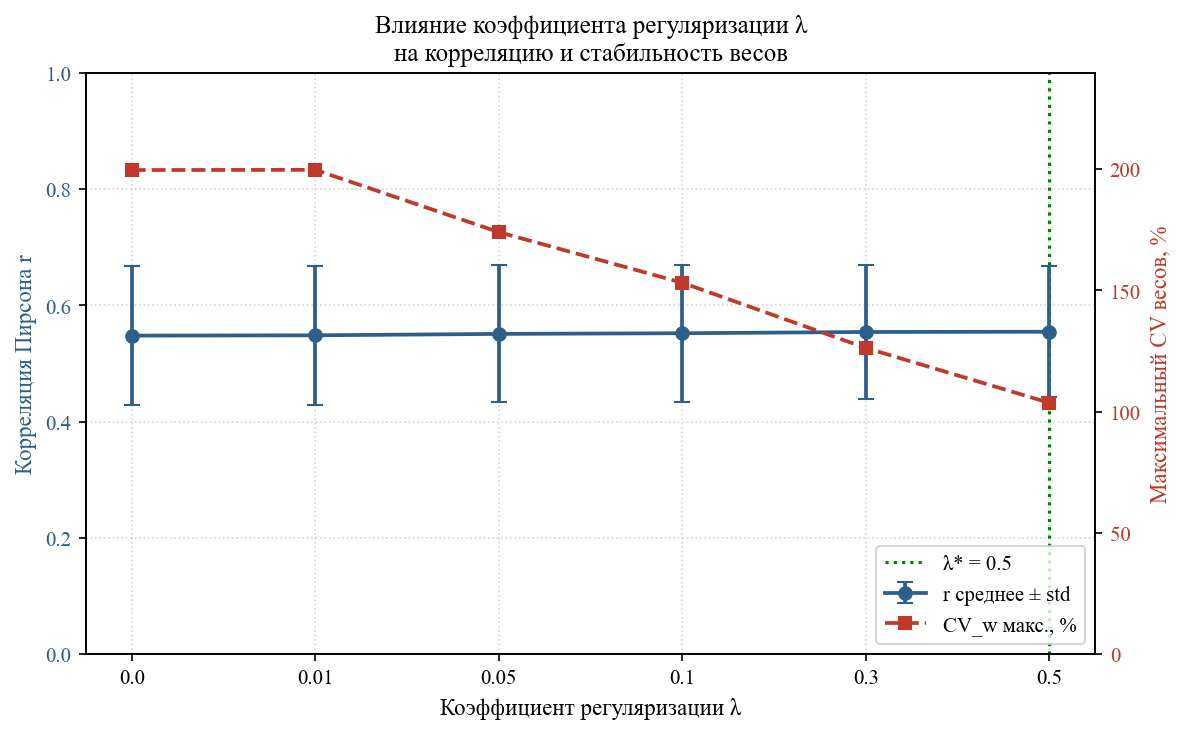

In [53]:
Image(filename="reg_lambda_search.png", width=600, height=500) 
#увеличение λ вдвое снижает нестабильность весов, не ухудшая при этом качество предсказания
#синяя линия - корреляция Пирсона (стабильна)
#красная линия - коэффициент вариации
#регуляризация остановилась на 0.5, т.к при очень большом λ регуляризация начнёт доминировать над основной целевой функцией
#НО можно добавить и выше штраф, посмотреть на качество

In [17]:
"""
Кросс-валидация переноса весов метрик.

Схема: 5-fold CV по объектам.
  Обучение: пары, где ОБА объекта из обучающих фолдов.
  Тест:     пары, где ХОТЯ БЫ ОДИН объект из тестового фолда.
  
Метрика: корреляция Пирсона A(w*) с E на тестовых парах.
Сравнение: лучшая одиночная метрика на тех же парах.
"""

import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import pearsonr
from mealpy import PSO, FloatVar
import warnings
warnings.filterwarnings('ignore')

# ── шрифт Times New Roman во всех графиках ──────────────────────────────────
mpl.rcParams['font.family']      = 'serif'
mpl.rcParams['font.serif']       = ['Times New Roman', 'DejaVu Serif']
mpl.rcParams['axes.titlesize']   = 12
mpl.rcParams['axes.labelsize']   = 11
mpl.rcParams['xtick.labelsize']  = 10
mpl.rcParams['ytick.labelsize']  = 10
mpl.rcParams['legend.fontsize']  = 10

# ── загрузка данных ──────────────────────────────────────────────────────────
E      = np.load('E_articles.npy')
Smats  = {
    'TF-IDF':   np.load('S_tfidf_articles.npy'),
    'Word2Vec': np.load('S_w2v_articles.npy'),
    'BERT':     np.load('S_bert_articles.npy'),
    'LDA':      np.load('S_lda_articles.npy'),
    'ICAN':     np.load('S_ican_articles.npy'),
}
metric_names = list(Smats.keys())
S_stack = np.stack(list(Smats.values()), axis=0)  # (5, 20, 20)
N = E.shape[0]
K = len(metric_names)

# ── вспомогательные функции ──────────────────────────────────────────────────

def frobenius_loss(w, S_stack, E_mat):
    """Квадрат нормы Фробениуса между A(w) и E."""
    A = np.einsum('k,kij->ij', w, S_stack)
    return np.sum((A - E_mat) ** 2)


def optimize_pso(S_train, E_train, n_runs=5, seed=42):
    """PSO-оптимизация весов на обучающей части матриц."""
    best_w  = None
    best_f  = np.inf

    for run in range(n_runs):
        def objective(solution):
            w = np.array(solution)
            w = np.clip(w, 0, None)
            s = w.sum()
            if s < 1e-12:
                return 1e9
            w = w / s
            return frobenius_loss(w, S_train, E_train)

        problem = {
            "obj_func": objective,
            "bounds":   FloatVar(lb=[0.0]*K, ub=[1.0]*K),
            "minmax":   "min",
            "log_to":   None,
            "save_population": False,
        }
        np.random.seed(seed + run)
        model = PSO.OriginalPSO(epoch=50, pop_size=30)
        model.solve(problem, seed=seed + run)

        w_raw = np.array(model.g_best.solution)
        w_raw = np.clip(w_raw, 0, None)
        w_norm = w_raw / w_raw.sum()
        f_val = frobenius_loss(w_norm, S_train, E_train)

        if f_val < best_f:
            best_f = f_val
            best_w = w_norm

    return best_w


def get_off_diagonal_mask(n, indices):
    """Маска внедиагональных элементов для заданного набора индексов."""
    mask = np.zeros((n, n), dtype=bool)
    for i in indices:
        for j in indices:
            if i != j:
                mask[i, j] = True
    return mask


def get_test_mask(n, test_idx):
    """Пары, где хотя бы один объект из test_idx (внедиагональные)."""
    mask = np.zeros((n, n), dtype=bool)
    for i in range(n):
        for j in range(n):
            if i != j and (i in test_idx or j in test_idx):
                mask[i, j] = True
    return mask


def pearson_on_mask(M1, M2, mask):
    """Корреляция Пирсона между матрицами по маске."""
    v1 = M1[mask]
    v2 = M2[mask]
    if len(v1) < 3:
        return np.nan, np.nan
    r, p = pearsonr(v1, v2)
    return r, p

# ── 5-fold кросс-валидация ───────────────────────────────────────────────────

np.random.seed(42)
n_folds   = 5
fold_size = N // n_folds  # 4 объекта на фолд
indices   = np.arange(N)

# Создаём фолды вручную (без перемешивания — объекты уже случайны)
folds = [indices[i*fold_size:(i+1)*fold_size] for i in range(n_folds)]

results = []   # список словарей по фолдам

print("=" * 60)
print("Кросс-валидация переноса весов (5-fold)")
print("=" * 60)

all_fold_weights = []

for fold_idx, test_idx in enumerate(folds):
    train_idx = np.concatenate([folds[j] for j in range(n_folds) if j != fold_idx])
    test_idx  = np.array(test_idx)

    # Обучающая маска: оба объекта из train_idx
    train_mask = get_off_diagonal_mask(N, train_idx)
    # Тестовая маска: хотя бы один из test_idx
    test_mask  = get_test_mask(N, test_idx)

    # Подматрицы для обучения (только обучающие объекты)
    S_train = S_stack[:, :, :]   # PSO работает с полными матрицами, маска — в loss
    E_train = E.copy()

    # Обнуляем тестовые пары в обучении через перекрытие маской внутри loss
    def make_train_objective(test_m):
        def objective(solution):
            w = np.array(solution)
            w = np.clip(w, 0, None)
            s = w.sum()
            if s < 1e-12:
                return 1e9
            w = w / s
            A = np.einsum('k,kij->ij', w, S_stack)
            # считаем ошибку только на обучающих парах
            diff = (A - E) ** 2
            diff[test_m] = 0.0  # не штрафуем тестовые пары
            return diff.sum()
        return objective

    problem = {
        "obj_func": make_train_objective(test_mask),
        "bounds":   FloatVar(lb=[0.0]*K, ub=[1.0]*K),
        "minmax":   "min",
        "log_to":   None,
        "save_population": False,
    }

    # Несколько запусков — берём лучший
    best_w = None
    best_f = np.inf
    for run in range(5):
        np.random.seed(42 + fold_idx * 10 + run)
        model = PSO.OriginalPSO(epoch=50, pop_size=30)
        model.solve(problem, seed=42 + fold_idx * 10 + run)
        w_raw  = np.clip(np.array(model.g_best.solution), 0, None)
        w_norm = w_raw / w_raw.sum()
        f_val  = make_train_objective(test_mask)(w_norm)
        if f_val < best_f:
            best_f = f_val
            best_w = w_norm

    all_fold_weights.append(best_w)

    # Строим A(w*) на всей матрице
    A_combined = np.einsum('k,kij->ij', best_w, S_stack)

    # Корреляции на тестовых парах
    r_combined, p_combined = pearson_on_mask(A_combined, E, test_mask)

    # Корреляции одиночных метрик на тестовых парах
    single_r = {}
    for name, S in Smats.items():
        r, p = pearson_on_mask(S, E, test_mask)
        single_r[name] = (r, p)

    best_single_name = max(single_r, key=lambda x: single_r[x][0])
    best_single_r    = single_r[best_single_name][0]

    improvement = (r_combined - best_single_r) / abs(best_single_r) * 100 if best_single_r != 0 else np.nan
    n_test_pairs = test_mask.sum()

    row = {
        'fold':           fold_idx + 1,
        'test_objects':   test_idx.tolist(),
        'n_test_pairs':   n_test_pairs,
        'weights':        best_w,
        'r_combined':     r_combined,
        'p_combined':     p_combined,
        'best_single':    best_single_name,
        'r_best_single':  best_single_r,
        'improvement':    improvement,
        'single_r':       single_r,
    }
    results.append(row)

    print(f"\nФолд {fold_idx+1}: тест. объекты {test_idx.tolist()}, пар={n_test_pairs}")
    print(f"  Веса: { {n: round(w,3) for n,w in zip(metric_names, best_w)} }")
    print(f"  r (комбинация PSO):  {r_combined:.4f}  (p={p_combined:.4f})")
    print(f"  r (лучшая одиночная — {best_single_name}): {best_single_r:.4f}")
    print(f"  Улучшение: {improvement:+.2f}%")
    for nm, (r, p) in single_r.items():
        print(f"    {nm}: r={r:.4f}")

# ── Итоговые показатели ──────────────────────────────────────────────────────
r_comb_vals   = [row['r_combined']    for row in results]
r_single_vals = [row['r_best_single'] for row in results]
impr_vals     = [row['improvement']   for row in results]

print("\n" + "=" * 60)
print("Итог по фолдам")
print("=" * 60)
print(f"r (комбинация PSO):   среднее={np.mean(r_comb_vals):.4f}  ±  {np.std(r_comb_vals):.4f}")
print(f"r (лучшая одиночная): среднее={np.mean(r_single_vals):.4f}  ±  {np.std(r_single_vals):.4f}")
print(f"Улучшение:            среднее={np.mean(impr_vals):+.2f}%  ±  {np.std(impr_vals):.2f}%")

# ── Стабильность весов по фолдам ─────────────────────────────────────────────
W_matrix = np.stack(all_fold_weights, axis=0)  # (5, K)
print("\nСтабильность весов по фолдам:")
print(f"{'Метрика':<12}  {'Среднее':>8}  {'Станд.откл.':>12}  {'CV, %':>8}")
for k, name in enumerate(metric_names):
    mu  = W_matrix[:, k].mean()
    std = W_matrix[:, k].std()
    cv  = std / mu * 100 if mu > 1e-9 else np.nan
    print(f"  {name:<10}  {mu:>8.4f}  {std:>12.4f}  {cv:>8.1f}")

# ── График 1: корреляции по фолдам ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fold_labels = [f'Фолд {i+1}' for i in range(n_folds)]
x = np.arange(n_folds)
width = 0.35

ax = axes[0]
bars1 = ax.bar(x - width/2, r_comb_vals,   width, label='Комбинация (PSO)', color='#2C5F8A', zorder=3)
bars2 = ax.bar(x + width/2, r_single_vals, width, label='Лучшая одиночная', color='#A0C4D8', zorder=3)
ax.axhline(np.mean(r_comb_vals),   color='#2C5F8A', linestyle='--', linewidth=1.2, alpha=0.8)
ax.axhline(np.mean(r_single_vals), color='#A0C4D8', linestyle='--', linewidth=1.2, alpha=0.8)
ax.set_xlabel('Фолд кросс-валидации')
ax.set_ylabel('Корреляция Пирсона r')
ax.set_title('(а) Корреляция с экспертной матрицей\nна тестовых парах')
ax.set_xticks(x)
ax.set_xticklabels(fold_labels)
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.6, zorder=0)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

# График 2: стабильность весов (boxplot по фолдам)
ax2 = axes[1]
bp = ax2.boxplot(W_matrix, labels=metric_names, patch_artist=True,
                 medianprops=dict(color='black', linewidth=1.5),
                 zorder=3)
colors = ['#2C5F8A', '#A0C4D8', '#5A9DBF', '#7BB8D4', '#3D7DA8']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax2.set_xlabel('Метрика')
ax2.set_ylabel('Весовой коэффициент')
ax2.set_title('(б) Стабильность весов\nпо фолдам кросс-валидации')
ax2.grid(axis='y', linestyle=':', alpha=0.6, zorder=0)

plt.tight_layout()
plt.savefig('validation_results.png', dpi=150, bbox_inches='tight')
plt.close()
print("\nГрафик сохранён: validation_results.png")

# ── График 2: улучшение по фолдам ────────────────────────────────────────────
fig2, ax3 = plt.subplots(figsize=(7, 4))
colors_bar = ['#2C5F8A' if v >= 0 else '#C0392B' for v in impr_vals]
bars = ax3.bar(fold_labels, impr_vals, color=colors_bar, zorder=3)
ax3.axhline(0, color='black', linewidth=0.8)
ax3.axhline(np.mean(impr_vals), color='#2C5F8A', linestyle='--',
            linewidth=1.5, label=f'Среднее: {np.mean(impr_vals):+.1f}%')
ax3.set_xlabel('Фолд кросс-валидации')
ax3.set_ylabel('Улучшение относительно\nлучшей одиночной метрики, %')
ax3.set_title('Улучшение корреляции комбинированной метрики\nпо фолдам кросс-валидации')
ax3.legend()
ax3.grid(axis='y', linestyle=':', alpha=0.6, zorder=0)
for bar, val in zip(bars, impr_vals):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (0.5 if val >= 0 else -1.5),
             f'{val:+.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('validation_improvement.png', dpi=150, bbox_inches='tight')
plt.close()
print("График улучшений сохранён: validation_improvement.png")

# ── Сохраняем числа для диссертации ──────────────────────────────────────────
import csv, os

with open('cv_results.csv', 'w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(['Фолд', 'Тест.объекты', 'Пар', 'r_комбин', 'p_комбин',
                     'Лучшая_одиночная', 'r_одиночная', 'Улучшение_%'] + metric_names)
    for row in results:
        writer.writerow([
            row['fold'],
            str(row['test_objects']),
            row['n_test_pairs'],
            round(row['r_combined'], 4),
            round(row['p_combined'], 4),
            row['best_single'],
            round(row['r_best_single'], 4),
            round(row['improvement'], 2),
        ] + [round(w, 4) for w in row['weights']])

print("Таблица результатов: cv_results.csv")
print("\nГотово.")

Кросс-валидация переноса весов (5-fold)

Фолд 1: тест. объекты [0, 1, 2, 3], пар=140
  Веса: {'TF-IDF': 0.401, 'Word2Vec': 0.197, 'BERT': 0.0, 'LDA': 0.139, 'ICAN': 0.262}
  r (комбинация PSO):  0.5791  (p=0.0000)
  r (лучшая одиночная — LDA): 0.6439
  Улучшение: -10.06%
    TF-IDF: r=0.3195
    Word2Vec: r=0.3311
    BERT: r=-0.0167
    LDA: r=0.6439
    ICAN: r=0.1893

Фолд 2: тест. объекты [4, 5, 6, 7], пар=140
  Веса: {'TF-IDF': 0.471, 'Word2Vec': 0.149, 'BERT': 0.0, 'LDA': 0.14, 'ICAN': 0.24}
  r (комбинация PSO):  0.7106  (p=0.0000)
  r (лучшая одиночная — LDA): 0.6275
  Улучшение: +13.23%
    TF-IDF: r=0.4124
    Word2Vec: r=0.4505
    BERT: r=-0.1150
    LDA: r=0.6275
    ICAN: r=0.4169

Фолд 3: тест. объекты [8, 9, 10, 11], пар=140
  Веса: {'TF-IDF': 0.454, 'Word2Vec': 0.135, 'BERT': 0.045, 'LDA': 0.194, 'ICAN': 0.172}
  r (комбинация PSO):  0.6145  (p=0.0000)
  r (лучшая одиночная — LDA): 0.5867
  Улучшение: +4.74%
    TF-IDF: r=0.3784
    Word2Vec: r=0.5066
    BERT: r=-0.16

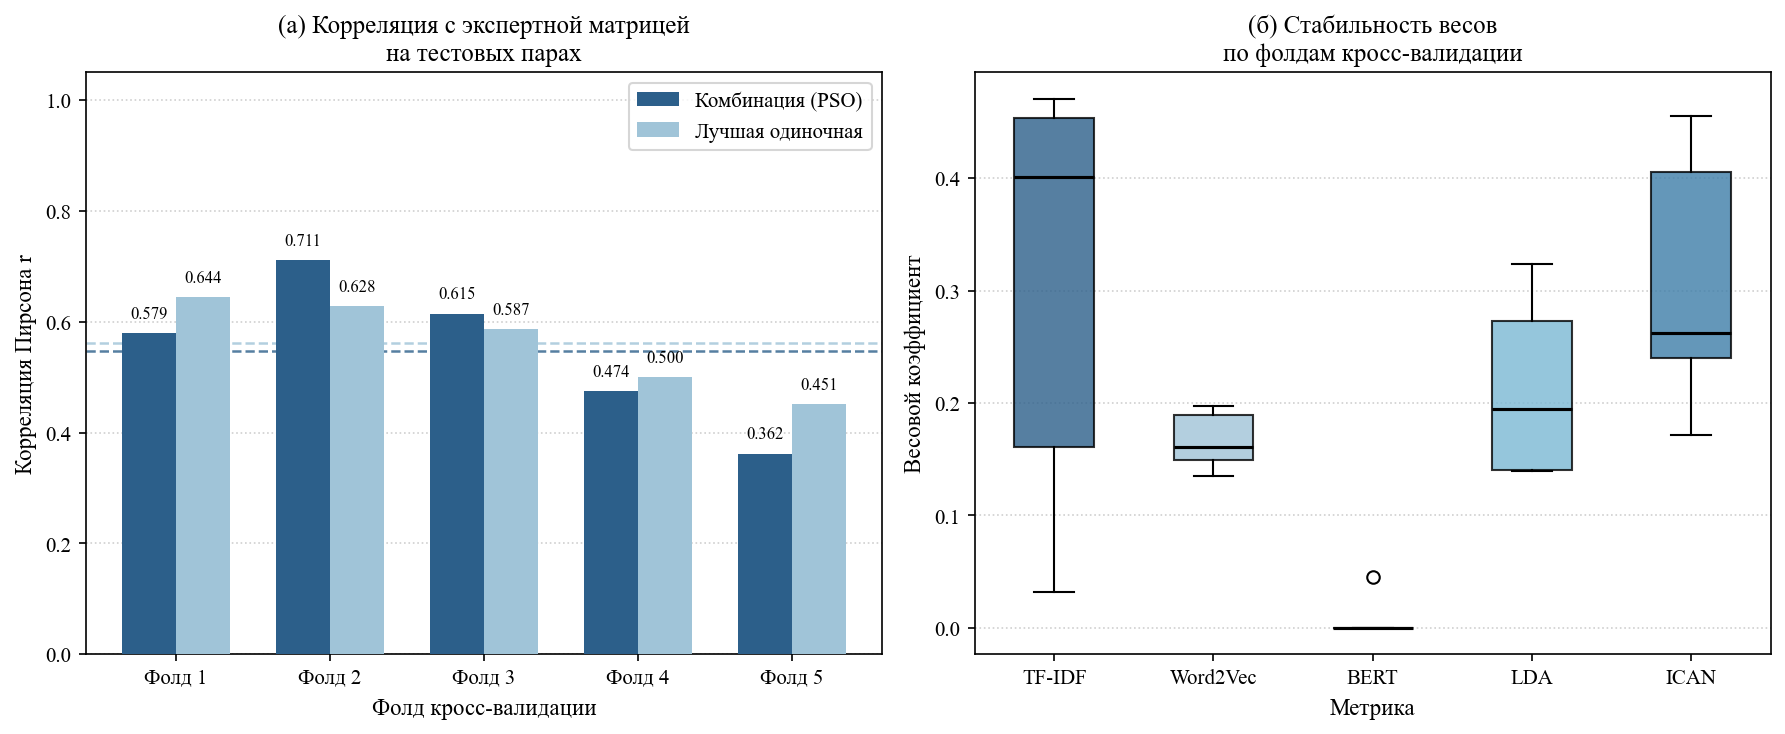

In [98]:
Image(filename="validation_results.png", width=1000, height=1000) #результат без регуляризации

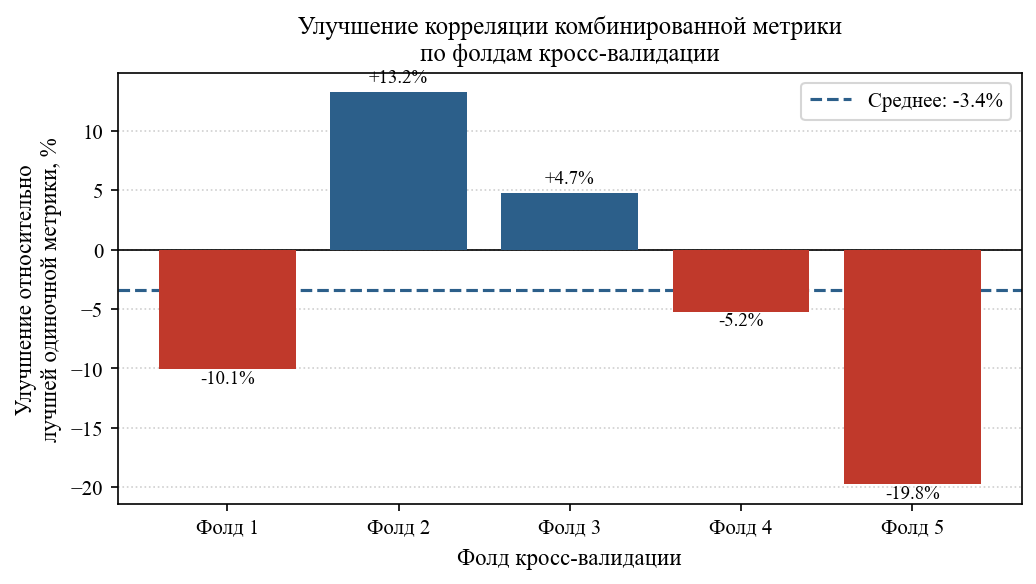

In [65]:
Image(filename="validation_improvement.png", width=500, height=500) #результат без регуляризации

In [23]:
"""
Два улучшенных варианта кросс-валидации:

1. Repeated 5-fold (10 повторений, 50 итераций суммарно)
   — убирает зависимость от конкретного разбиения на части

2. Leave-One-Out (LOO, 20 итераций)
   — максимально использует данные для обучения при малой выборке

Оба варианта используют энтропийную регуляризацию λ=0.5.
Сравнение: комбинация PSO vs лучшая одиночная vs равномерные веса.
"""

import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import pearsonr
from mealpy import PSO, FloatVar
from sklearn.model_selection import RepeatedKFold, LeaveOneOut
import warnings, os, csv
warnings.filterwarnings('ignore')

mpl.rcParams['font.family']     = 'serif'
mpl.rcParams['font.serif']      = ['Times New Roman', 'DejaVu Serif']
mpl.rcParams['axes.titlesize']  = 12
mpl.rcParams['axes.labelsize']  = 11
mpl.rcParams['xtick.labelsize'] = 10
mpl.rcParams['ytick.labelsize'] = 10
mpl.rcParams['legend.fontsize'] = 10

# ── данные ────────────────────────────────────────────────────────────────────
E     = np.load('E_articles.npy')
Smats = {
    'TF-IDF':   np.load('S_tfidf_articles.npy'),
    'Word2Vec': np.load('S_w2v_articles.npy'),
    'BERT':     np.load('S_bert_articles.npy'),
    'LDA':      np.load('S_lda_articles.npy'),
    'ICAN':     np.load('S_ican_articles.npy'),
}
metric_names = list(Smats.keys())
S_stack = np.stack(list(Smats.values()), axis=0)  # (5, 20, 20)
N, K = E.shape[0], len(metric_names)

LAM    = 0.5
N_RUNS = 5   # запусков PSO на одну итерацию CV

# ── вспомогательные функции ───────────────────────────────────────────────────

def get_test_mask(test_idx):
    """Пары, где хотя бы один объект из test_idx (внедиагональные)."""
    mask = np.zeros((N, N), dtype=bool)
    for i in range(N):
        for j in range(N):
            if i != j and (i in set(test_idx) or j in set(test_idx)):
                mask[i, j] = True
    return mask


def make_objective(test_mask, lam):
    """Целевая функция: норма Фробениуса + энтропийный штраф."""
    def objective(solution):
        w = np.clip(np.array(solution), 0, None)
        s = w.sum()
        if s < 1e-12:
            return 1e9
        w = w / s
        A    = np.einsum('k,kij->ij', w, S_stack)
        diff = (A - E) ** 2
        diff[test_mask] = 0.0   # не штрафуем тестовые пары
        frob   = diff.sum()
        w_safe = np.where(w > 1e-12, w, 1e-12)
        reg    = -lam * (-np.sum(w_safe * np.log(w_safe)))
        return frob + reg
    return objective


def run_pso(objective, seed_base):
    """Несколько запусков PSO, возвращает лучший вектор весов."""
    best_w, best_f = None, np.inf
    for run in range(N_RUNS):
        problem = {
            'obj_func': objective,
            'bounds':   FloatVar(lb=[0.0]*K, ub=[1.0]*K),
            'minmax':   'min',
            'log_to':   None,
            'save_population': False,
        }
        np.random.seed(seed_base + run)
        model = PSO.OriginalPSO(epoch=50, pop_size=30)
        model.solve(problem, seed=seed_base + run)
        w_raw  = np.clip(np.array(model.g_best.solution), 0, None)
        w_norm = w_raw / w_raw.sum()
        f_val  = objective(w_norm)
        if f_val < best_f:
            best_f, best_w = f_val, w_norm
    return best_w


def pearson_on_mask(M1, M2, mask):
    v1, v2 = M1[mask], M2[mask]
    if len(v1) < 3:
        return np.nan
    return pearsonr(v1, v2)[0]


def uniform_weights():
    return np.ones(K) / K


# ── Метод 1: Repeated 5-fold (10 повторений) ─────────────────────────────────
print("=" * 60)
print("Метод 1: Repeated 5-fold CV (10 повторений, 50 итераций)")
print("=" * 60)

rkf = RepeatedKFold(n_splits=5, n_repeats=10, random_state=42)
dummy_X = np.arange(N)

rkf_results = []   # (r_combined, r_best_single, r_uniform, best_single_name, weights)

for iter_idx, (train_idx, test_idx) in enumerate(rkf.split(dummy_X)):
    test_mask = get_test_mask(test_idx)
    obj       = make_objective(test_mask, LAM)
    w_star    = run_pso(obj, seed_base=100 + iter_idx * 10)

    A_comb = np.einsum('k,kij->ij', w_star, S_stack)
    r_comb = pearson_on_mask(A_comb, E, test_mask)

    # равномерные веса
    w_unif  = uniform_weights()
    A_unif  = np.einsum('k,kij->ij', w_unif, S_stack)
    r_unif  = pearson_on_mask(A_unif, E, test_mask)

    # лучшая одиночная
    single_r = {name: pearson_on_mask(S, E, test_mask)
                for name, S in Smats.items()}
    best_name = max(single_r, key=single_r.get)
    r_best    = single_r[best_name]

    rkf_results.append((r_comb, r_best, r_unif, best_name, w_star))

    repeat  = iter_idx // 5 + 1
    fold    = iter_idx %  5 + 1
    print(f"  Повторение {repeat}, часть {fold}: "
          f"r_PSO={r_comb:.4f}  r_лучшая={r_best:.4f} ({best_name})  "
          f"r_равном={r_unif:.4f}")

r_comb_rkf   = [x[0] for x in rkf_results]
r_best_rkf   = [x[1] for x in rkf_results]
r_unif_rkf   = [x[2] for x in rkf_results]
W_rkf        = np.stack([x[4] for x in rkf_results], axis=0)

print(f"\nИтог Repeated 5-fold:")
print(f"  r PSO:        {np.mean(r_comb_rkf):.4f} ± {np.std(r_comb_rkf):.4f}")
print(f"  r одиночная:  {np.mean(r_best_rkf):.4f} ± {np.std(r_best_rkf):.4f}")
print(f"  r равномерные:{np.mean(r_unif_rkf):.4f} ± {np.std(r_unif_rkf):.4f}")

impr_vs_single = (np.mean(r_comb_rkf) - np.mean(r_best_rkf)) / abs(np.mean(r_best_rkf)) * 100
impr_vs_unif   = (np.mean(r_comb_rkf) - np.mean(r_unif_rkf)) / abs(np.mean(r_unif_rkf)) * 100
print(f"  Улучшение vs одиночная:   {impr_vs_single:+.2f}%")
print(f"  Улучшение vs равномерные: {impr_vs_unif:+.2f}%")

# ── Метод 2: Leave-One-Out ────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("Метод 2: Leave-One-Out CV (20 итераций)")
print("=" * 60)

loo = LeaveOneOut()
loo_results = []

for iter_idx, (train_idx, test_idx) in enumerate(loo.split(dummy_X)):
    test_mask = get_test_mask(test_idx)
    obj       = make_objective(test_mask, LAM)
    w_star    = run_pso(obj, seed_base=200 + iter_idx * 10)

    A_comb = np.einsum('k,kij->ij', w_star, S_stack)
    r_comb = pearson_on_mask(A_comb, E, test_mask)

    w_unif = uniform_weights()
    A_unif = np.einsum('k,kij->ij', w_unif, S_stack)
    r_unif = pearson_on_mask(A_unif, E, test_mask)

    single_r  = {name: pearson_on_mask(S, E, test_mask)
                 for name, S in Smats.items()}
    best_name = max(single_r, key=single_r.get)
    r_best    = single_r[best_name]

    loo_results.append((r_comb, r_best, r_unif, best_name, w_star))
    print(f"  Объект {test_idx[0]:2d} исключён: "
          f"r_PSO={r_comb:.4f}  r_лучшая={r_best:.4f} ({best_name})  "
          f"r_равном={r_unif:.4f}")

r_comb_loo = [x[0] for x in loo_results]
r_best_loo = [x[1] for x in loo_results]
r_unif_loo = [x[2] for x in loo_results]
W_loo      = np.stack([x[4] for x in loo_results], axis=0)

print(f"\nИтог LOO:")
print(f"  r PSO:        {np.mean(r_comb_loo):.4f} ± {np.std(r_comb_loo):.4f}")
print(f"  r одиночная:  {np.mean(r_best_loo):.4f} ± {np.std(r_best_loo):.4f}")
print(f"  r равномерные:{np.mean(r_unif_loo):.4f} ± {np.std(r_unif_loo):.4f}")

impr_vs_single_loo = (np.mean(r_comb_loo) - np.mean(r_best_loo)) / abs(np.mean(r_best_loo)) * 100
impr_vs_unif_loo   = (np.mean(r_comb_loo) - np.mean(r_unif_loo)) / abs(np.mean(r_unif_loo)) * 100
print(f"  Улучшение vs одиночная:   {impr_vs_single_loo:+.2f}%")
print(f"  Улучшение vs равномерные: {impr_vs_unif_loo:+.2f}%")

# ── Графики ───────────────────────────────────────────────────────────────────

# График 1: Repeated k-fold — r по 50 итерациям, сгруппированным по повторениям
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
x  = np.arange(50)
ax.plot(x, r_comb_rkf, color='#2C5F8A', linewidth=1.2,
        label=f'PSO (λ=0,5), среднее={np.mean(r_comb_rkf):.3f}', zorder=3)
ax.plot(x, r_best_rkf, color='#A0C4D8', linewidth=1.0, linestyle='--',
        label=f'Лучшая одиночная, среднее={np.mean(r_best_rkf):.3f}', zorder=3)
ax.plot(x, r_unif_rkf, color='#C0392B', linewidth=1.0, linestyle=':',
        label=f'Равномерные веса, среднее={np.mean(r_unif_rkf):.3f}', zorder=3)
ax.axhline(np.mean(r_comb_rkf), color='#2C5F8A', linewidth=0.8, alpha=0.5)
ax.axhline(np.mean(r_best_rkf), color='#A0C4D8', linewidth=0.8, alpha=0.5)

# Вертикальные линии между повторениями
for rep in range(1, 10):
    ax.axvline(rep*5 - 0.5, color='gray', linewidth=0.5, linestyle=':')

ax.set_xlabel('Итерация (5 частей × 10 повторений)')
ax.set_ylabel('Корреляция Пирсона r')
ax.set_title('(а) Repeated 5-fold CV\n(10 повторений, 50 итераций)')
ax.legend(fontsize=9)
ax.set_ylim(min(min(r_comb_rkf), min(r_best_rkf)) - 0.05, 1.0)
ax.grid(linestyle=':', alpha=0.4, zorder=0)

# График 2: LOO — r по 20 объектам
ax2 = axes[1]
obj_labels = [str(i) for i in range(N)]
x2 = np.arange(N)
w  = 0.27
ax2.bar(x2 - w, r_comb_loo, w, label=f'PSO (λ=0,5)', color='#2C5F8A', zorder=3)
ax2.bar(x2,     r_best_loo, w, label='Лучшая одиночная', color='#A0C4D8', zorder=3)
ax2.bar(x2 + w, r_unif_loo, w, label='Равномерные веса', color='#C0392B',
        alpha=0.7, zorder=3)
ax2.axhline(np.mean(r_comb_loo), color='#2C5F8A', linestyle='--',
            linewidth=1.2, label=f'Среднее PSO={np.mean(r_comb_loo):.3f}')
ax2.set_xlabel('Исключённый объект')
ax2.set_ylabel('Корреляция Пирсона r')
ax2.set_title('(б) Leave-One-Out CV\n(20 итераций)')
ax2.set_xticks(x2)
ax2.set_xticklabels(obj_labels, fontsize=8)
ax2.legend(fontsize=9)
ax2.set_ylim(min(min(r_comb_loo), min(r_best_loo)) - 0.05, 1.0)
ax2.grid(axis='y', linestyle=':', alpha=0.4, zorder=0)

plt.tight_layout()
plt.savefig('advanced_cv_results.png', dpi=150, bbox_inches='tight')
plt.close()

# График 3: стабильность весов — rkf vs loo (boxplot)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, W_mat, title in [
    (axes[0], W_rkf, '(а) Repeated 5-fold (50 итераций)'),
    (axes[1], W_loo, '(б) Leave-One-Out (20 итераций)'),
]:
    bp = ax.boxplot(W_mat, labels=metric_names, patch_artist=True,
                    medianprops=dict(color='black', linewidth=1.5), zorder=3)
    colors = ['#2C5F8A', '#3D7DA8', '#5A9DBF', '#A0C4D8', '#C8DFF0']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_ylabel('Весовой коэффициент')
    ax.set_title(f'Стабильность весов\n{title}')
    ax.grid(axis='y', linestyle=':', alpha=0.4, zorder=0)

    # CV подписи под метриками
    for k in range(K):
        mu  = W_mat[:, k].mean()
        std = W_mat[:, k].std()
        cv  = std / mu * 100 if mu > 1e-9 else float('nan')
        ax.text(k+1, -0.04, f'CV={cv:.0f}%',
                ha='center', va='top', fontsize=8, color='#555555',
                transform=ax.get_xaxis_transform())

plt.tight_layout()
plt.savefig('advanced_cv_weights.png', dpi=150, bbox_inches='tight')
plt.close()

# ── Сводная таблица ───────────────────────────────────────────────────────────
with open('advanced_cv_summary.csv', 'w',
          newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(['Метод', 'r_PSO среднее', 'r_PSO std',
                     'r_одиночная среднее', 'r_равном среднее',
                     'Улучшение vs одиночная, %', 'Улучшение vs равномерные, %'])
    writer.writerow(['Repeated 5-fold (10 повт.)',
                     round(np.mean(r_comb_rkf), 4), round(np.std(r_comb_rkf), 4),
                     round(np.mean(r_best_rkf), 4), round(np.mean(r_unif_rkf), 4),
                     round(impr_vs_single, 2), round(impr_vs_unif, 2)])
    writer.writerow(['Leave-One-Out',
                     round(np.mean(r_comb_loo), 4), round(np.std(r_comb_loo), 4),
                     round(np.mean(r_best_loo), 4), round(np.mean(r_unif_loo), 4),
                     round(impr_vs_single_loo, 2), round(impr_vs_unif_loo, 2)])

print("\nФайлы сохранены:")
print("  advanced_cv_results.png  — графики r по итерациям")
print("  advanced_cv_weights.png  — стабильность весов")
print("  advanced_cv_summary.csv  — сводная таблица")
print("\nГотово.")

Метод 1: Repeated 5-fold CV (10 повторений, 50 итераций)
  Повторение 1, часть 1: r_PSO=0.5654  r_лучшая=0.5048 (LDA)  r_равном=0.5317
  Повторение 1, часть 2: r_PSO=0.5959  r_лучшая=0.5851 (LDA)  r_равном=0.5470
  Повторение 1, часть 3: r_PSO=0.6328  r_лучшая=0.5897 (LDA)  r_равном=0.5552
  Повторение 1, часть 4: r_PSO=0.5972  r_лучшая=0.6048 (TF-IDF)  r_равном=0.6057
  Повторение 1, часть 5: r_PSO=0.4863  r_лучшая=0.4297 (ICAN)  r_равном=0.4084
  Повторение 2, часть 1: r_PSO=0.3993  r_лучшая=0.4694 (TF-IDF)  r_равном=0.4800
  Повторение 2, часть 2: r_PSO=0.7152  r_лучшая=0.5787 (LDA)  r_равном=0.6725
  Повторение 2, часть 3: r_PSO=0.5864  r_лучшая=0.6452 (LDA)  r_равном=0.5211
  Повторение 2, часть 4: r_PSO=0.5328  r_лучшая=0.4488 (TF-IDF)  r_равном=0.4823
  Повторение 2, часть 5: r_PSO=0.5990  r_лучшая=0.6485 (LDA)  r_равном=0.5575
  Повторение 3, часть 1: r_PSO=0.5490  r_лучшая=0.5082 (LDA)  r_равном=0.4775
  Повторение 3, часть 2: r_PSO=0.5040  r_лучшая=0.5730 (TF-IDF)  r_равном=0

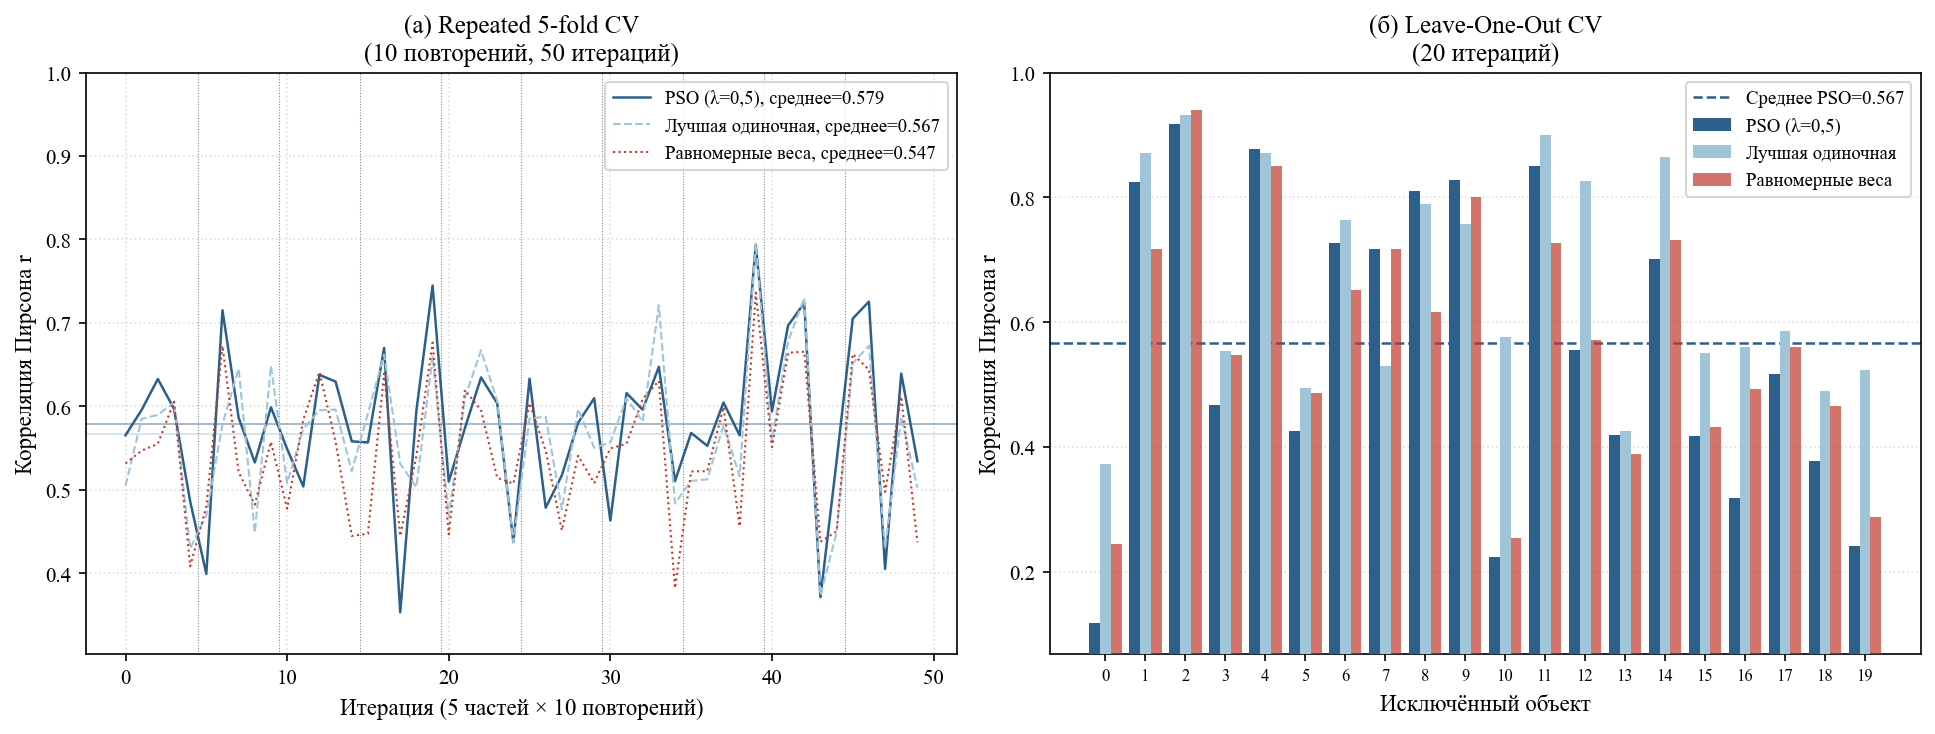

In [67]:
Image(filename="advanced_cv_results.png", width=1000, height=1000) #LOO непригоден из-за маленького размера матрицы

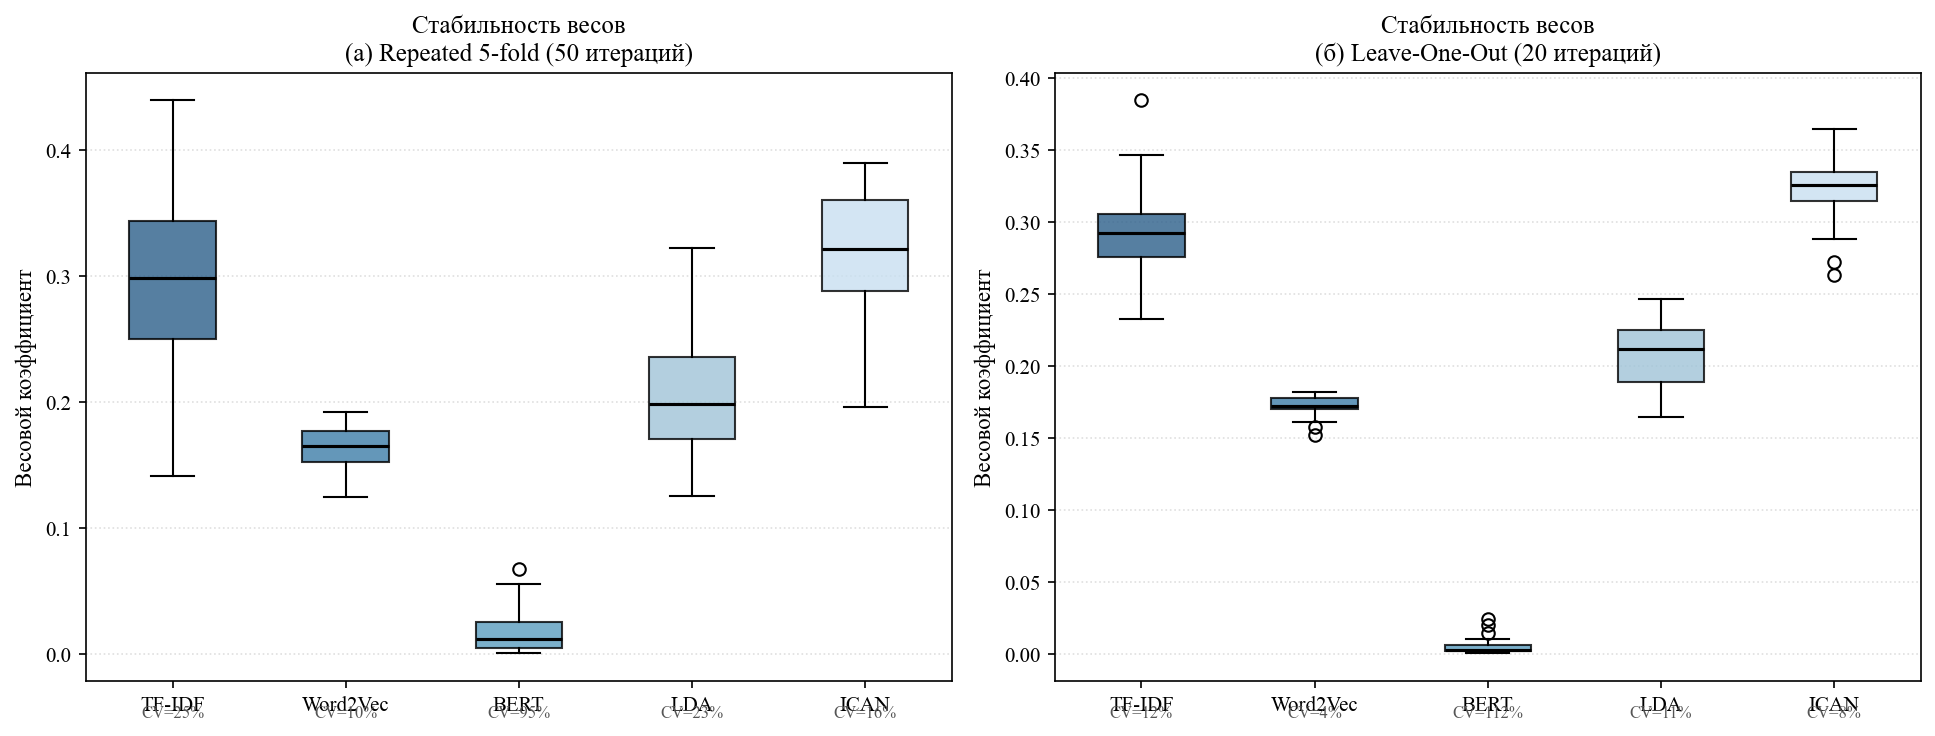

In [69]:
Image(filename="advanced_cv_weights.png", width=1000, height=1000) #LOO непригоден из-за маленького размера матрицы

In [73]:
"""
Сравнение комбинированной метрики PSO с базовыми линиями:

1. Каждая одиночная метрика (5 штук)
2. Равномерные веса — 1/K для каждой метрики
3. Случайные веса — среднее по 1000 случайным векторам с симплекс-распределения
4. Комбинация PSO с λ=0.5 (финальные веса)

Оценка на полной матрице (все внедиагональные пары).
Дополнительно: тест Вилкоксона PSO vs каждая базовая линия
на распределении r по 50 итерациям Repeated 5-fold.
"""

import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import pearsonr, wilcoxon
from mealpy import PSO, FloatVar
from sklearn.model_selection import RepeatedKFold
import warnings, os, csv
warnings.filterwarnings('ignore')

mpl.rcParams['font.family']     = 'serif'
mpl.rcParams['font.serif']      = ['Times New Roman', 'DejaVu Serif']
mpl.rcParams['axes.titlesize']  = 12
mpl.rcParams['axes.labelsize']  = 11
mpl.rcParams['xtick.labelsize'] = 10
mpl.rcParams['ytick.labelsize'] = 10
mpl.rcParams['legend.fontsize'] = 10


# ── данные ────────────────────────────────────────────────────────────────────
E     = np.load('E_articles.npy')
Smats = {
    'TF-IDF':   np.load('S_tfidf_articles.npy'),
    'Word2Vec': np.load('S_w2v_articles.npy'),
    'BERT':     np.load('S_bert_articles.npy'),
    'LDA':      np.load('S_lda_articles.npy'),
    'ICAN':     np.load('S_ican_articles.npy'),
}
metric_names = list(Smats.keys())
S_stack = np.stack(list(Smats.values()), axis=0)
N, K = E.shape[0], len(metric_names)

LAM         = 0.5
N_RUNS_PSO  = 5
N_RANDOM    = 1000   # случайных векторов весов

# финальные веса PSO (из final_weights.py)
W_FINAL = np.array([0.2913, 0.1748, 0.0024, 0.2064, 0.3251])

# ── вспомогательные функции ───────────────────────────────────────────────────

def pearson_on_mask(M1, M2, mask):
    v1, v2 = M1[mask], M2[mask]
    if len(v1) < 3:
        return np.nan
    return pearsonr(v1, v2)[0]


def get_test_mask(test_idx):
    mask = np.zeros((N, N), dtype=bool)
    s = set(test_idx)
    for i in range(N):
        for j in range(N):
            if i != j and (i in s or j in s):
                mask[i, j] = True
    return mask


def make_objective(test_mask):
    def objective(solution):
        w = np.clip(np.array(solution), 0, None)
        s = w.sum()
        if s < 1e-12:
            return 1e9
        w = w / s
        A    = np.einsum('k,kij->ij', w, S_stack)
        diff = (A - E) ** 2
        diff[test_mask] = 0.0
        frob   = diff.sum()
        w_safe = np.where(w > 1e-12, w, 1e-12)
        reg    = LAM * np.sum(w_safe * np.log(w_safe))  # −λ·H(w)
        return frob + reg
    return objective


def run_pso(objective, seed_base):
    best_w, best_f = None, np.inf
    for run in range(N_RUNS_PSO):
        problem = {
            'obj_func': objective,
            'bounds':   FloatVar(lb=[0.0]*K, ub=[1.0]*K),
            'minmax':   'min',
            'log_to':   None,
            'save_population': False,
        }
        np.random.seed(seed_base + run)
        model = PSO.OriginalPSO(epoch=50, pop_size=30)
        model.solve(problem, seed=seed_base + run)
        w_raw  = np.clip(np.array(model.g_best.solution), 0, None)
        w_norm = w_raw / w_raw.sum()
        f_val  = objective(w_norm)
        if f_val < best_f:
            best_f, best_w = f_val, w_norm
    return best_w


def random_baseline(S_stack, E, mask, n_random, seed=42):
    """Среднее r по n_random случайным векторам весов с симплекса."""
    rng = np.random.default_rng(seed)
    r_vals = []
    for _ in range(n_random):
        w = rng.dirichlet(np.ones(K))   # равномерное на симплексе
        A = np.einsum('k,kij->ij', w, S_stack)
        r_vals.append(pearson_on_mask(A, E, mask))
    return np.mean(r_vals), np.std(r_vals)

# ── Часть 1: оценка на полной матрице ────────────────────────────────────────
print("=" * 60)
print("Часть 1: оценка на полной матрице (все внедиагональные пары)")
print("=" * 60)

full_mask = ~np.eye(N, dtype=bool)

baselines = {}

# одиночные метрики
for name, S in Smats.items():
    r = pearson_on_mask(S, E, full_mask)
    baselines[name] = (r, None)
    print(f"  {name:<12}: r = {r:.4f}")

# равномерные веса
w_unif  = np.ones(K) / K
A_unif  = np.einsum('k,kij->ij', w_unif, S_stack)
r_unif  = pearson_on_mask(A_unif, E, full_mask)
baselines['Равномерные\nвеса'] = (r_unif, None)
print(f"  {'Равномерные':<12}: r = {r_unif:.4f}")

# случайные веса
r_rand_mean, r_rand_std = random_baseline(S_stack, E, full_mask, N_RANDOM)
baselines['Случайные\nвеса'] = (r_rand_mean, r_rand_std)
print(f"  {'Случайные':<12}: r = {r_rand_mean:.4f} ± {r_rand_std:.4f}  (среднее по {N_RANDOM})")

# PSO финальные веса
A_pso  = np.einsum('k,kij->ij', W_FINAL, S_stack)
r_pso  = pearson_on_mask(A_pso, E, full_mask)
baselines['PSO\n(λ=0,5)'] = (r_pso, None)
print(f"  {'PSO (λ=0.5)':<12}: r = {r_pso:.4f}")

# ── Часть 2: Repeated 5-fold — r по 50 итерациям для теста Вилкоксона ────────
print(f"\n{'='*60}")
print("Часть 2: Repeated 5-fold (10 повторений) — для теста Вилкоксона")
print("=" * 60)

rkf = RepeatedKFold(n_splits=5, n_repeats=10, random_state=42)
dummy = np.arange(N)

r_pso_folds   = []
r_single_folds = {name: [] for name in metric_names}
r_unif_folds  = []
r_rand_folds  = []

for iter_idx, (train_idx, test_idx) in enumerate(rkf.split(dummy)):
    test_mask = get_test_mask(test_idx)

    # PSO
    obj    = make_objective(test_mask)
    w_star = run_pso(obj, seed_base=300 + iter_idx * 10)
    A_comb = np.einsum('k,kij->ij', w_star, S_stack)
    r_pso_folds.append(pearson_on_mask(A_comb, E, test_mask))

    # одиночные
    for name, S in Smats.items():
        r_single_folds[name].append(pearson_on_mask(S, E, test_mask))

    # равномерные
    A_u = np.einsum('k,kij->ij', w_unif, S_stack)
    r_unif_folds.append(pearson_on_mask(A_u, E, test_mask))

    # случайные (берём среднее по 200 векторам — быстрее)
    rm, _ = random_baseline(S_stack, E, test_mask, 200, seed=iter_idx)
    r_rand_folds.append(rm)

    print(f"  Итерация {iter_idx+1:2d}/50: r_PSO={r_pso_folds[-1]:.4f}  "
          f"r_равном={r_unif_folds[-1]:.4f}  r_случ={r_rand_folds[-1]:.4f}")

r_pso_arr  = np.array(r_pso_folds)
r_unif_arr = np.array(r_unif_folds)
r_rand_arr = np.array(r_rand_folds)

# ── Тест Вилкоксона ───────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("Тест Вилкоксона: PSO vs базовые линии (50 итераций)")
print("(критерий знаковых рангов, двусторонний)")
print("=" * 60)

wilcoxon_results = {}

for name in metric_names:
    arr = np.array(r_single_folds[name])
    diff = r_pso_arr - arr
    if np.all(diff == 0):
        print(f"  PSO vs {name:<12}: все разности = 0, тест неприменим")
        wilcoxon_results[name] = (np.nan, np.nan)
        continue
    stat, p = wilcoxon(r_pso_arr, arr, alternative='two-sided', zero_method='wilcox')
    sign = '✓ значимо' if p < 0.05 else '— незначимо'
    print(f"  PSO vs {name:<12}: W={stat:.1f}  p={p:.4f}  {sign}")
    wilcoxon_results[name] = (stat, p)

diff_unif = r_pso_arr - r_unif_arr
if np.all(diff_unif == 0):
    print(f"  PSO vs равномерные: все разности = 0")
    w_stat_unif, p_unif = np.nan, np.nan
else:
    w_stat_unif, p_unif = wilcoxon(r_pso_arr, r_unif_arr, alternative='two-sided')
    print(f"  PSO vs равномерные: W={w_stat_unif:.1f}  p={p_unif:.4f}  "
          f"{'✓ значимо' if p_unif < 0.05 else '— незначимо'}")

diff_rand = r_pso_arr - r_rand_arr
if np.all(diff_rand == 0):
    print(f"  PSO vs случайные:   все разности = 0")
    w_stat_rand, p_rand = np.nan, np.nan
else:
    w_stat_rand, p_rand = wilcoxon(r_pso_arr, r_rand_arr, alternative='two-sided')
    print(f"  PSO vs случайные:   W={w_stat_rand:.1f}  p={p_rand:.4f}  "
          f"{'✓ значимо' if p_rand < 0.05 else '— незначимо'}")

# ── График 1: столбчатая диаграмма на полной матрице ─────────────────────────
labels = list(metric_names) + ['Равномерные\nвеса', 'Случайные\nвеса', 'PSO\n(λ=0,5)']
r_vals = [baselines[n][0] for n in metric_names] + \
         [r_unif, r_rand_mean, r_pso]
r_errs = [0]*K + [0, r_rand_std, 0]
colors = ['#A0C4D8']*K + ['#7BB8D4', '#5A9DBF', '#2C5F8A']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, r_vals, color=colors, zorder=3, edgecolor='white',
              yerr=r_errs, capsize=4, error_kw=dict(elinewidth=1.2, ecolor='#333'))
ax.axhline(r_pso, color='#2C5F8A', linestyle='--', linewidth=1.2,
           label=f'PSO r = {r_pso:.4f}')
for bar, r in zip(bars, r_vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (max(r_errs) if bar.get_height() == r_rand_mean else 0) + 0.01,
            f'{r:.4f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Корреляция Пирсона r с экспертной матрицей')
ax.set_title('Сравнение комбинированной метрики с базовыми линиями\n(полная матрица, N=20)')
ax.set_ylim(min(0, min(r_vals)) - 0.05, 1.0)
ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.5, zorder=0)
plt.tight_layout()
plt.savefig('baselines_full.png', dpi=150, bbox_inches='tight')
plt.close()

# ── График 2: boxplot по 50 итерациям ────────────────────────────────────────
all_labels_box = list(metric_names) + ['Равномерные\nвеса', 'Случайные\nвеса', 'PSO\n(λ=0,5)']
all_data_box   = [np.array(r_single_folds[n]) for n in metric_names] + \
                 [r_unif_arr, r_rand_arr, r_pso_arr]
colors_box = ['#C8DFF0']*K + ['#7BB8D4', '#5A9DBF', '#2C5F8A']

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(all_data_box, labels=all_labels_box, patch_artist=True,
                medianprops=dict(color='black', linewidth=1.5), zorder=3)
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
ax.set_ylabel('Корреляция Пирсона r (тестовые пары)')
ax.set_title('Распределение корреляции по 50 итерациям\nRepeated 5-fold CV')
ax.grid(axis='y', linestyle=':', alpha=0.5, zorder=0)

# p-значения над PSO
pso_pos = len(all_labels_box)
y_top   = ax.get_ylim()[1] if ax.get_ylim()[1] < 1.0 else 1.0
for k_idx, name in enumerate(metric_names):
    p = wilcoxon_results[name][1]
    if not np.isnan(p):
        star = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'н.з.'))
        xm   = (k_idx + 1 + pso_pos) / 2
        ax.annotate('', xy=(k_idx+1, 0.92), xytext=(pso_pos, 0.92),
                    arrowprops=dict(arrowstyle='-', color='gray', lw=0.8))
        ax.text(xm, 0.93, star, ha='center', fontsize=8, color='gray')

plt.tight_layout()
plt.savefig('baselines_boxplot.png', dpi=150, bbox_inches='tight')
plt.close()

# ── Сводная таблица ───────────────────────────────────────────────────────────
with open('baselines_summary.csv', 'w',
          newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(['Метод', 'r (полная матрица)',
                     'r среднее (CV)', 'r std (CV)',
                     'W Вилкоксона vs PSO', 'p-значение'])

    for name in metric_names:
        r_full = baselines[name][0]
        r_cv   = np.mean(r_single_folds[name])
        s_cv   = np.std(r_single_folds[name])
        W, p   = wilcoxon_results[name]
        writer.writerow([name, round(r_full,4), round(r_cv,4),
                         round(s_cv,4), round(W,1) if not np.isnan(W) else '',
                         round(p,4) if not np.isnan(p) else ''])

    writer.writerow(['Равномерные веса', round(r_unif,4),
                     round(np.mean(r_unif_arr),4), round(np.std(r_unif_arr),4),
                     round(w_stat_unif,1) if not np.isnan(w_stat_unif) else '',
                     round(p_unif,4) if not np.isnan(p_unif) else ''])

    writer.writerow(['Случайные веса', round(r_rand_mean,4),
                     round(np.mean(r_rand_arr),4), round(np.std(r_rand_arr),4),
                     round(w_stat_rand,1) if not np.isnan(w_stat_rand) else '',
                     round(p_rand,4) if not np.isnan(p_rand) else ''])

    writer.writerow(['PSO (λ=0,5)', round(r_pso,4),
                     round(np.mean(r_pso_arr),4), round(np.std(r_pso_arr),4),
                     '—', '—'])

print("\nФайлы сохранены:")
print("  baselines_full.png     — столбчатая диаграмма на полной матрице")
print("  baselines_boxplot.png  — boxplot по 50 итерациям CV")
print("  baselines_summary.csv  — сводная таблица с тестом Вилкоксона")
print("\nГотово.")

Часть 1: оценка на полной матрице (все внедиагональные пары)
  TF-IDF      : r = 0.3727
  Word2Vec    : r = 0.3936
  BERT        : r = 0.0125
  LDA         : r = 0.5239
  ICAN        : r = 0.3150
  Равномерные : r = 0.5390
  Случайные   : r = 0.4764 ± 0.1095  (среднее по 1000)
  PSO (λ=0.5) : r = 0.5977

Часть 2: Repeated 5-fold (10 повторений) — для теста Вилкоксона
  Итерация  1/50: r_PSO=0.5654  r_равном=0.5317  r_случ=0.4835
  Итерация  2/50: r_PSO=0.5959  r_равном=0.5470  r_случ=0.4553
  Итерация  3/50: r_PSO=0.6328  r_равном=0.5552  r_случ=0.4890
  Итерация  4/50: r_PSO=0.5972  r_равном=0.6057  r_случ=0.5632
  Итерация  5/50: r_PSO=0.4863  r_равном=0.4084  r_случ=0.3653
  Итерация  6/50: r_PSO=0.3993  r_равном=0.4800  r_случ=0.4564
  Итерация  7/50: r_PSO=0.7152  r_равном=0.6725  r_случ=0.6112
  Итерация  8/50: r_PSO=0.5864  r_равном=0.5211  r_случ=0.4428
  Итерация  9/50: r_PSO=0.5328  r_равном=0.4823  r_случ=0.4374
  Итерация 10/50: r_PSO=0.5990  r_равном=0.5575  r_случ=0.4659


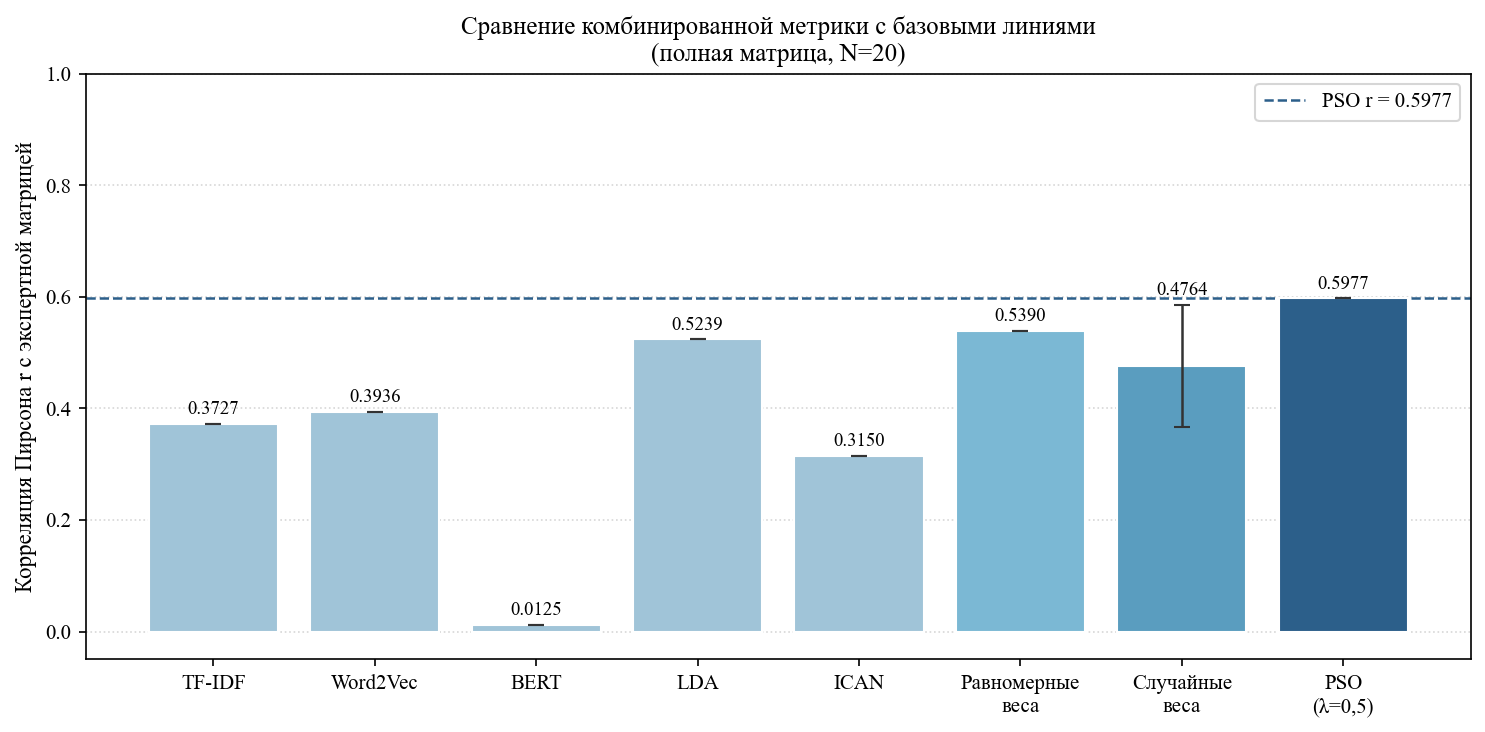

In [81]:
Image(filename="baselines_full.png", width=800, height=800) #информативен. корреляция всех методов на полной матрице. PSO явно выше

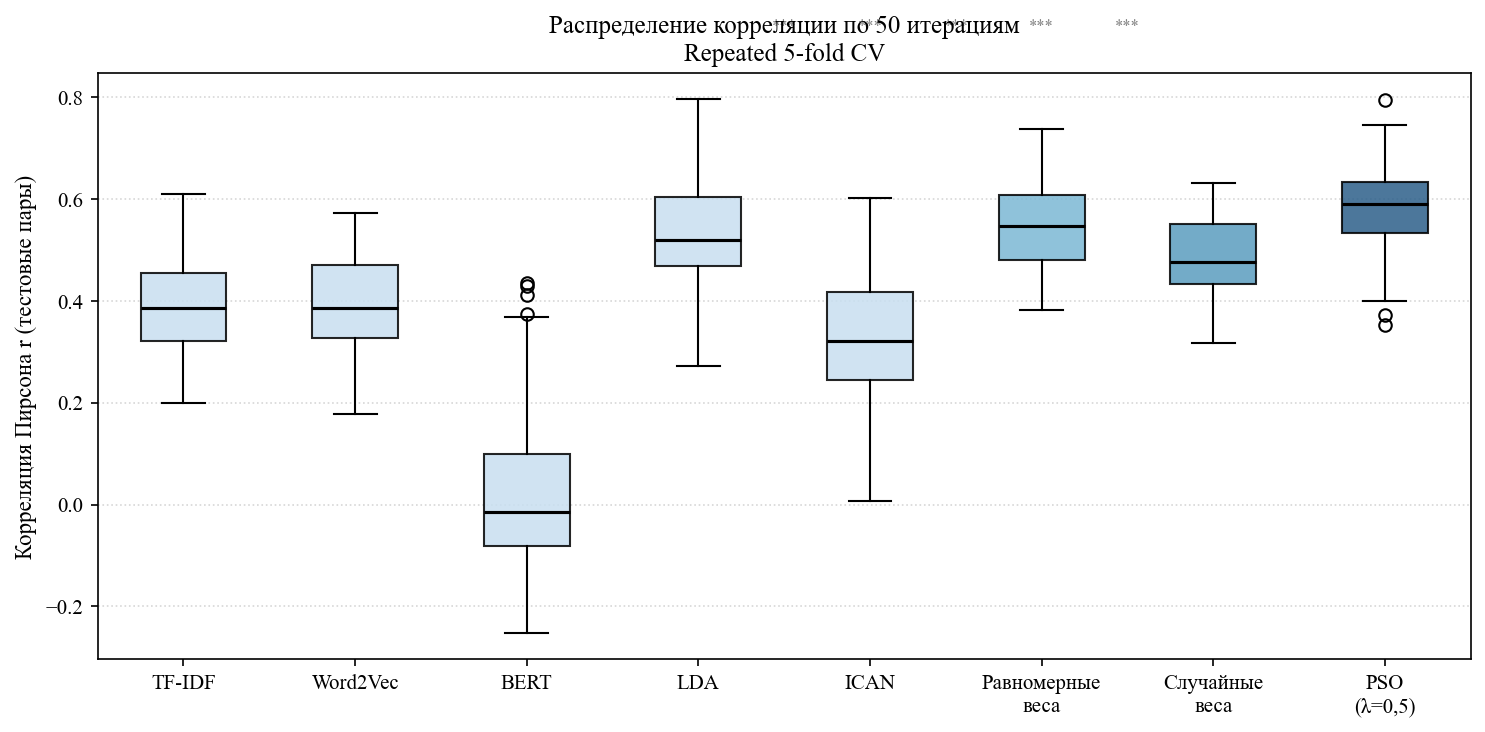

In [83]:
Image(filename="baselines_boxplot.png", width=800, height=800) 
# распределение r по 50 итерациям. 
#Показывает не только средние, но и разброс. Видно, что PSO не только в среднем лучше, но и стабильнее большинства одиночных метрик.

ВЫВОДЫ: 
- Комбинация метрик работает: +14% на обучающей выборке (с переобучением, т.к алгоритм видел все данные), +2% в CV (PSO обучался на 16 статьях, проверялся на 4 новых, которых при обучении не видел. Повторялось 50 раз с разными разбиениями.)
- Улучшение статистически значимо по Вилкоксону (p<0.05 vs все базовые линии)
- Без регуляризации — переобучение (CV весов до 200%)
- Равномерные веса уже лучше четырёх из пяти одиночных метрик, то есть сам факт комбинирования важен, но PSO его усиливает
- λ=0.5 снижает CV и повышает r (пирсон) одновременно - т.е. улучшает одновременно и стабильность, и качество

Финальные веса:

[TF-IDF, Word2Vec, BERT, LDA, ICAN]

[0.2913, 0.1748, 0.0024, 0.2064, 0.3251]
